Name: Riya Dilip Deorukhkar

USC ID: 6691519296

Github: riyadd20

## 1. Transfer Learning for Image Classification

### (a) In this problem, we are trying to build a classifier that distinguishes images of nine types of waste.

### (b) Data Exploration and Pre-processing

#### i. Images are numbered in each folder. Select the first 80% of the images in each folder as your training set and the rest as the test set. You can encode your classes using one-hot encoding.

In [ ]:
import os, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16, ResNet50, ResNet101, EfficientNetB0
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, EarlyStopping

In [ ]:
import os
print(os.listdir('../data/RealWaste'))

['4-Metal', '2-Food Organics', '8-Textile Trash', '9-Vegetation', '7-Plastic', '6-Paper', '1-Cardboard', '5-Miscellaneous Trash', '3-Glass']


In [ ]:
base_dir = '../data/RealWaste'

categories = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
image_counts = [len(os.listdir(os.path.join(base_dir, cat))) for cat in categories]

df_folders = pd.DataFrame({
    'Class ID': range(1, len(categories)+1),
    'Folder Name': categories,
    'Image Count': image_counts
})

df_folders

,Class ID,Folder Name,Image Count
0,1,1-Cardboard,461
1,2,2-Food Organics,411
2,3,3-Glass,420
3,4,4-Metal,790
4,5,5-Miscellaneous Trash,495
5,6,6-Paper,500
6,7,7-Plastic,921
7,8,8-Textile Trash,318
8,9,9-Vegetation,436


In [ ]:
# Reference: chatgpt: help with stratified train-test splits and one hot encoding
X_train, y_train = [], []
X_test, y_test = [], []

for class_idx, category in enumerate(categories):
    category_path = os.path.join(base_dir, category)
    image_files = sorted([f for f in os.listdir(category_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    if not image_files:
        print(f"Warning: No images found in {category}")
        continue

    split_idx = int(0.8 * len(image_files))
    X_train.extend([os.path.join(category_path, img) for img in image_files[:split_idx]])
    y_train.extend([class_idx] * split_idx)
    X_test.extend([os.path.join(category_path, img) for img in image_files[split_idx:]])
    y_test.extend([class_idx] * (len(image_files) - split_idx))

X_train, X_test = np.array(X_train), np.array(X_test)
y_train = to_categorical(y_train, num_classes=len(categories))
y_test = to_categorical(y_test, num_classes=len(categories))

print(f"\nSummary:")
print(f"Total training images: {len(X_train)}")
print(f"Total test images: {len(X_test)}")
print(f"Number of classes: {len(categories)}")
print("\nOne-hot encoding:")
for class_idx, category in enumerate(categories):
    class_indices = np.where(np.argmax(y_train, axis=1) == class_idx)[0]
    if len(class_indices) > 0:
        first_sample = class_indices[0]
        print(f"{category}: {y_train[first_sample]}")
    else:
        print(f"{category}: No samples found in training set")


Summary:
Total training images: 3798
Total test images: 954
Number of classes: 9

One-hot encoding:
1-Cardboard: [1. 0. 0. 0. 0. 0. 0. 0. 0.]
2-Food Organics: [0. 1. 0. 0. 0. 0. 0. 0. 0.]
3-Glass: [0. 0. 1. 0. 0. 0. 0. 0. 0.]
4-Metal: [0. 0. 0. 1. 0. 0. 0. 0. 0.]
5-Miscellaneous Trash: [0. 0. 0. 0. 1. 0. 0. 0. 0.]
6-Paper: [0. 0. 0. 0. 0. 1. 0. 0. 0.]
7-Plastic: [0. 0. 0. 0. 0. 0. 1. 0. 0.]
8-Textile Trash: [0. 0. 0. 0. 0. 0. 0. 1. 0.]
9-Vegetation: [0. 0. 0. 0. 0. 0. 0. 0. 1.]


#### ii. In case all the images do not have the same size, zero-pad or resize the images in your dataset. This can be done using various tools, including OpenCV

In [ ]:
def prepare_split(base_dir, dest_dir, train_pct=0.64, val_pct=0.16):
    for label in sorted(os.listdir(base_dir)):
        full_path = os.path.join(base_dir, label)
        if not os.path.isdir(full_path):
            continue

        images = sorted([img for img in os.listdir(full_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])
        random.shuffle(images)
        n_total = len(images)
        n_train = int(train_pct * n_total)
        n_val = int(val_pct * n_total)

        splits = {
            'train': images[:n_train],
            'val': images[n_train:n_train+n_val],
            'test': images[n_train+n_val:]
        }

        for split_type, files in splits.items():
            split_path = os.path.join(dest_dir, split_type, label)
            os.makedirs(split_path, exist_ok=True)
            for file in files:
                shutil.copy(os.path.join(full_path, file), os.path.join(split_path, file))

prepare_split('../data/RealWaste', '../data/images_split')

In [ ]:
train_data = tf.keras.utils.image_dataset_from_directory(
    '../data/images_split/train', image_size=(224, 224), batch_size=5, label_mode='categorical', shuffle='False')

val_data = tf.keras.utils.image_dataset_from_directory(
    '../data/images_split/val', image_size=(224, 224), batch_size=5, label_mode='categorical', shuffle='False')

test_data = tf.keras.utils.image_dataset_from_directory(
    '../data/images_split/test', image_size=(224, 224), batch_size=5, label_mode='categorical', shuffle='False')

AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

Found 3038 files belonging to 9 classes.
Found 756 files belonging to 9 classes.
Found 958 files belonging to 9 classes.


### (c) Transfer Learning

#### i. When dealing with classification of relatively small image datasets, deep networks may not perform very well because of not having enough data to train them. In such cases, one usually uses transfer learning, which uses deep learning models that are trained on very large datasets such as ImageNet as feature extractors. The idea is that such deep networks have learned to extract meaningful features from an image using their layers, and those features can be used in learning other tasks. In order to do that, usually the last layer or the last few layers of the pre-trained network are removed, and the response of the layer before the removed layers to the images in the new dataset is used as a feature vector to train one more multiple replacement layers. In this project, you will use pre-trained models ResNet50, ResNet100, EfficientNetB0, and VGG16. For those pre-trained networks, you will only train the last fully connected layer, and will freeze all layers before them (i.e. we do not change their parameters during training) and use the outputs of the penultimate layer in the original pre-trained model as the features extracted from each image.

#### ii. To perform empirical regularization, crop, randomly zoom, rotate, flip, contrast, and translate images in your training set for image augmentation. You can use various tools to do this, including OpenCV.

#### iii. Use ReLU activation functions in the last layer and a softmax layer, along with L2 regularization, batch normalization, and a dropout rate of 20% as well as ADAM optimizer. Use multinomial cross entropy loss. You can try any batch size, but a batch size of 5 seems reasonable.

In [ ]:
#Reference chat gpt: in seeting up the architechture
def define_model_with_augmentation(base_model, num_classes=9):
    base_model.trainable = False

    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomContrast(0.3),
    ], name="augmentation")

    inputs = layers.Input(shape=(224, 224, 3), name="inputLayer")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation="relu", name='relu_dense_1')(x)
    x = layers.Dropout(0.2, name="dropout_1")(x)
    x = layers.Dense(128, activation="relu", name='relu_dense_2')(x)
    x = layers.Dense(20, activation="relu", name='relu_dense_3')(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="activationLayer")(x)
    model = models.Model(inputs, outputs, name="CustomModel")
    optimizer = Adam(learning_rate=1e-5)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

##### VGG16

In [ ]:
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
vgg_model = define_model_with_augmentation(vgg)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "CustomModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputLayer (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_1 (Dense)            │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_2 (Dense)            │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_3 (Dense)            │ (None, 20)             │         2,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activationLayer (Dense)         │ (None, 9)              │           189 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,047,825 (57.40 MB)

 Trainable params: 332,113 (1.27 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

##### RESNET50

In [ ]:
resnet50 = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
resnet50_model = define_model_with_augmentation(resnet50)
resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "CustomModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputLayer (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_1 (Dense)            │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_2 (Dense)            │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_3 (Dense)            │ (None, 20)             │         2,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activationLayer (Dense)         │ (None, 9)              │           189 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,713,425 (94.27 MB)

 Trainable params: 1,121,617 (4.28 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

##### RESNET101

In [ ]:
resnet101 = ResNet101(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
resnet101_model = define_model_with_augmentation(resnet101)
resnet101_model.summary()

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "CustomModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputLayer (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet101 (Functional)          │ (None, 7, 7, 2048)     │    42,658,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_1 (Dense)            │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_2 (Dense)            │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_3 (Dense)            │ (None, 20)             │         2,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activationLayer (Dense)         │ (None, 9)              │           189 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,783,889 (167.02 MB)

 Trainable params: 1,121,617 (4.28 MB)

 Non-trainable params: 42,662,272 (162.74 MB)

##### EFFICIENTNETB0

In [ ]:
efficientnet = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
efficientnet_model = define_model_with_augmentation(efficientnet)
efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "CustomModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputLayer (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_1 (Dense)            │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_2 (Dense)            │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_3 (Dense)            │ (None, 20)             │         2,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activationLayer (Dense)         │ (None, 9)              │           189 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,778,996 (18.23 MB)

 Trainable params: 726,865 (2.77 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

#### iv. Train the networks for at least 50 epochs (preferably 100 epochs) and perform early stopping using the validation set. Use a randomly selected subset of 20% of each class as the validation set. Keep the network parameters that have the lowest validation error. Plot the training and validation errors vs. epochs

##### VGG16

Epoch 1/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0981 - loss: 2.3424

608/608 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - accuracy: 0.0981 - loss: 2.3423 - val_accuracy: 0.1468 - val_loss: 2.2225
Epoch 2/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1508 - loss: 2.1962

608/608 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.1508 - loss: 2.1962 - val_accuracy: 0.2063 - val_loss: 2.0962
Epoch 3/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1943 - loss: 2.1173

608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.1944 - loss: 2.1172 - val_accuracy: 0.2487 - val_loss: 2.0095
Epoch 4/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2487 - loss: 2.0405

608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.2487 - loss: 2.0404 - val_accuracy: 0.2989 - val_loss: 1.9226
Epoch 5/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2781 - loss: 1.9697

...

608/608 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.7262 - loss: 0.7890 - val_accuracy: 0.7275 - val_loss: 0.8396
Epoch 78/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7427 - loss: 0.7629 - val_accuracy: 0.7275 - val_loss: 0.8403
Epoch 79/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7313 - loss: 0.7997 - val_accuracy: 0.7288 - val_loss: 0.8407
Epoch 80/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7216 - loss: 0.7869 - val_accuracy: 0.7262 - val_loss: 0.8411
Epoch 81/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7325 - loss: 0.7575 - val_accuracy: 0.7288 - val_loss: 0.8500
Epoch 82/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7389 - loss: 0.7796

608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7389 - loss: 0.7795 - val_accuracy: 0.7315 - val_loss: 0.8379
Epoch 83/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7347 - loss: 0.7658 - val_accuracy: 0.7275 - val_loss: 0.8449
Epoch 84/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7368 - loss: 0.7570

608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7368 - loss: 0.7570 - val_accuracy: 0.7315 - val_loss: 0.8358
Epoch 85/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7433 - loss: 0.7696 - val_accuracy: 0.7275 - val_loss: 0.8406
Epoch 86/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7388 - loss: 0.7356

608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7388 - loss: 0.7356 - val_accuracy: 0.7302 - val_loss: 0.8241
Epoch 87/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7443 - loss: 0.7496 - val_accuracy: 0.7275 - val_loss: 0.8346
Epoch 88/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7343 - loss: 0.7835 - val_accuracy: 0.7275 - val_loss: 0.8334
Epoch 89/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7344 - loss: 0.7418 - val_accuracy: 0.7275 - val_loss: 0.8383
Epoch 90/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7356 - loss: 0.7448 - val_accuracy: 0.7354 - val_loss: 0.8276
Epoch 91/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7601 - loss: 0.6941 - val_accuracy: 0.7275 - val_loss: 0.8362
Epoch 92/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7405 - loss: 0.7494 - val_accuracy: 0.7368 - val_loss: 0.8270
Epoch 93/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7463 - loss: 0.7323

608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7444 - loss: 0.7363 - val_accuracy: 0.7315 - val_loss: 0.8153
Epoch 95/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7448 - loss: 0.7370 - val_accuracy: 0.7315 - val_loss: 0.8244
Epoch 96/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7403 - loss: 0.7286 - val_accuracy: 0.7354 - val_loss: 0.8285
Epoch 97/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7385 - loss: 0.7215 - val_accuracy: 0.7368 - val_loss: 0.8164
Epoch 98/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7619 - loss: 0.7002 - val_accuracy: 0.7341 - val_loss: 0.8220
Epoch 99/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7591 - loss: 0.7250 - val_accuracy: 0.7381 - val_loss: 0.8218
Epoch 100/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.7657 - loss: 0.7099 - val_accuracy: 0.7315 - val_loss: 0.8282


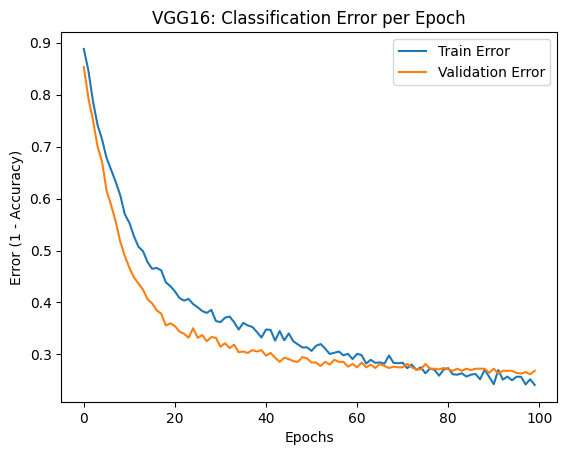

In [ ]:
# Reference: chatgpt: help with implementing the custom early stopping logic
class DelayedEarlyStopping(EarlyStopping):
    def __init__(self, start_epoch=50, **kwargs):
        super().__init__(**kwargs)
        self.start_epoch = start_epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.start_epoch:
            super().on_epoch_end(epoch, logs)
        else:
            self.wait = 0
            self.stopped_epoch = 0

early = DelayedEarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    start_epoch=50
)

checkpoint = ModelCheckpoint("best_vgg_model.h5", save_best_only=True)

history = vgg_model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[early, checkpoint]
)

train_error = [1 - acc for acc in history.history['accuracy']]
val_error = [1 - acc for acc in history.history['val_accuracy']]

plt.plot(train_error, label='Train Error')
plt.plot(val_error, label='Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.show()

In [ ]:
def get_true_and_predicted_labels(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    return np.array(y_true), np.array(y_pred)

y_train_true, y_train_pred = get_true_and_predicted_labels(vgg_model, train_data)
y_val_true, y_val_pred = get_true_and_predicted_labels(vgg_model, val_data)
y_test_true, y_test_pred = get_true_and_predicted_labels(vgg_model, test_data)

print("Train Accuracy:", accuracy_score(y_train_true, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val_true, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test_true, y_test_pred))

Train Accuracy: 0.8011849901250823
Validation Accuracy: 0.7619047619047619
Test Accuracy: 0.7453027139874739


##### RESNET50

Epoch 1/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1886 - loss: 2.3516

608/608 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.1886 - loss: 2.3515 - val_accuracy: 0.2421 - val_loss: 2.0236
Epoch 2/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2556 - loss: 1.9654

608/608 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.2557 - loss: 1.9653 - val_accuracy: 0.3532 - val_loss: 1.7418
Epoch 3/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3681 - loss: 1.7544

608/608 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.3681 - loss: 1.7544 - val_accuracy: 0.4603 - val_loss: 1.5181
Epoch 4/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4252 - loss: 1.6232

608/608 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.4253 - loss: 1.6231 - val_accuracy: 0.5384 - val_loss: 1.3654
Epoch 5/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5179 - loss: 1.4614

...

608/608 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8231 - loss: 0.5469 - val_accuracy: 0.7447 - val_loss: 0.7765
Epoch 39/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8284 - loss: 0.4926 - val_accuracy: 0.7354 - val_loss: 0.7881
Epoch 40/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8364 - loss: 0.4988

608/608 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8364 - loss: 0.4988 - val_accuracy: 0.7500 - val_loss: 0.7747
Epoch 41/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8264 - loss: 0.4958

608/608 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8264 - loss: 0.4958 - val_accuracy: 0.7394 - val_loss: 0.7700
Epoch 42/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8421 - loss: 0.4787 - val_accuracy: 0.7460 - val_loss: 0.7825
Epoch 43/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8431 - loss: 0.4859 - val_accuracy: 0.7460 - val_loss: 0.7719
Epoch 44/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8461 - loss: 0.4798

608/608 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8461 - loss: 0.4798 - val_accuracy: 0.7434 - val_loss: 0.7684
Epoch 45/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8420 - loss: 0.4536 - val_accuracy: 0.7447 - val_loss: 0.7797
Epoch 46/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8418 - loss: 0.4662 - val_accuracy: 0.7526 - val_loss: 0.7808
Epoch 47/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8451 - loss: 0.4632

608/608 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8451 - loss: 0.4632 - val_accuracy: 0.7487 - val_loss: 0.7635
Epoch 48/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8631 - loss: 0.4223 - val_accuracy: 0.7513 - val_loss: 0.7726
Epoch 49/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8425 - loss: 0.4571 - val_accuracy: 0.7460 - val_loss: 0.7948
Epoch 50/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8537 - loss: 0.4270 - val_accuracy: 0.7553 - val_loss: 0.7705
Epoch 51/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8705 - loss: 0.4052 - val_accuracy: 0.7540 - val_loss: 0.7834
Epoch 52/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8407 - loss: 0.4337 - val_accuracy: 0.7474 - val_loss: 0.7888
Epoch 53/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8612 - loss: 0.4265 - val_accuracy: 0.7526 - val_loss: 0.7983
Epoch 54/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8648 - loss: 0.4058

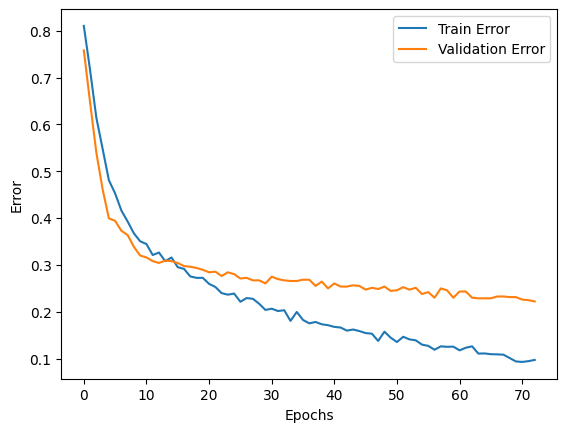

In [ ]:
class DelayedEarlyStopping(EarlyStopping):
    def __init__(self, start_epoch=50, **kwargs):
        super().__init__(**kwargs)
        self.start_epoch = start_epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.start_epoch:
            super().on_epoch_end(epoch, logs)
        else:
            self.wait = 0
            self.stopped_epoch = 0

early_resnet = DelayedEarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    start_epoch=50
)

checkpoint_resnet = ModelCheckpoint("best_resnet50_model.h5", save_best_only=True)

history_resnet = resnet50_model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[early_resnet, checkpoint_resnet]
)

train_error = [1 - acc for acc in history_resnet.history['accuracy']]
val_error = [1 - acc for acc in history_resnet.history['val_accuracy']]

plt.plot(train_error, label='Train Error')
plt.plot(val_error, label='Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.show()

In [ ]:
def get_true_and_predicted_labels(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    return np.array(y_true), np.array(y_pred)

y_train_true, y_train_pred = get_true_and_predicted_labels(resnet50_model, train_data)
y_val_true, y_val_pred = get_true_and_predicted_labels(resnet50_model, val_data)
y_test_true, y_test_pred = get_true_and_predicted_labels(resnet50_model, test_data)

print("Train Accuracy:", accuracy_score(y_train_true, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val_true, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test_true, y_test_pred))

Train Accuracy: 0.8624094799210007
Validation Accuracy: 0.7645502645502645
Test Accuracy: 0.7860125260960334


##### RESNET101

Epoch 1/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1342 - loss: 2.3904

608/608 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - accuracy: 0.1342 - loss: 2.3902 - val_accuracy: 0.2407 - val_loss: 2.0879
Epoch 2/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2755 - loss: 2.0183

608/608 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.2756 - loss: 2.0182 - val_accuracy: 0.3889 - val_loss: 1.8173
Epoch 3/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3438 - loss: 1.8577

608/608 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.3439 - loss: 1.8575 - val_accuracy: 0.4603 - val_loss: 1.5928
Epoch 4/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4170 - loss: 1.6980

608/608 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.4171 - loss: 1.6978 - val_accuracy: 0.5304 - val_loss: 1.4127
Epoch 5/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4739 - loss: 1.5318

...

608/608 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.7918 - loss: 0.5832 - val_accuracy: 0.7394 - val_loss: 0.7977
Epoch 33/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.7939 - loss: 0.5810 - val_accuracy: 0.7434 - val_loss: 0.8047
Epoch 34/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8053 - loss: 0.5512 - val_accuracy: 0.7447 - val_loss: 0.8005
Epoch 35/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8012 - loss: 0.5637 - val_accuracy: 0.7474 - val_loss: 0.8113
Epoch 36/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8169 - loss: 0.5265 - val_accuracy: 0.7500 - val_loss: 0.8050
Epoch 37/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8111 - loss: 0.5659 - val_accuracy: 0.7606 - val_loss: 0.8029
Epoch 38/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8263 - loss: 0.5223 - val_accuracy: 0.7579 - val_loss: 0.7985
Epoch 39/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8203 - loss: 0.5117

608/608 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.8606 - loss: 0.4042 - val_accuracy: 0.7593 - val_loss: 0.7962
Epoch 53/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8785 - loss: 0.3822 - val_accuracy: 0.7579 - val_loss: 0.7972
Epoch 54/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8548 - loss: 0.4144 - val_accuracy: 0.7659 - val_loss: 0.7994
Epoch 55/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8632 - loss: 0.3901

608/608 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.8632 - loss: 0.3902 - val_accuracy: 0.7698 - val_loss: 0.7953
Epoch 56/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8863 - loss: 0.3679

608/608 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.8862 - loss: 0.3679 - val_accuracy: 0.7685 - val_loss: 0.7928
Epoch 57/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8759 - loss: 0.3632 - val_accuracy: 0.7738 - val_loss: 0.8014
Epoch 58/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8823 - loss: 0.3544

608/608 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.8823 - loss: 0.3545 - val_accuracy: 0.7672 - val_loss: 0.7833
Epoch 59/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.8895 - loss: 0.3568 - val_accuracy: 0.7685 - val_loss: 0.7933
Epoch 60/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8789 - loss: 0.3512 - val_accuracy: 0.7672 - val_loss: 0.7967
Epoch 61/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8821 - loss: 0.3496 - val_accuracy: 0.7659 - val_loss: 0.8105
Epoch 62/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8840 - loss: 0.3475 - val_accuracy: 0.7619 - val_loss: 0.7965
Epoch 63/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8898 - loss: 0.3228 - val_accuracy: 0.7619 - val_loss: 0.8047
Epoch 64/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.9039 - loss: 0.3047 - val_accuracy: 0.7606 - val_loss: 0.8246
Epoch 65/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.8871 - loss: 0.3328

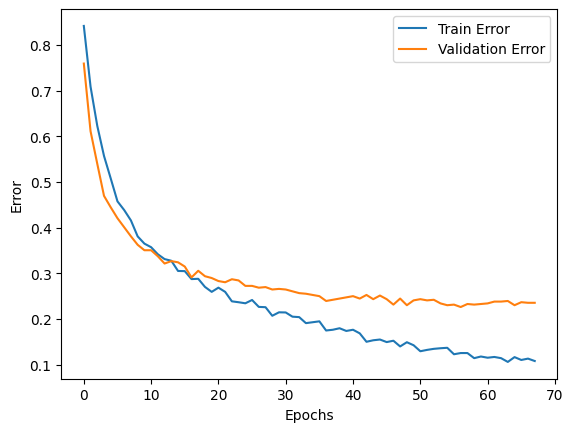

In [ ]:
class DelayedEarlyStopping(EarlyStopping):
    def __init__(self, start_epoch=50, **kwargs):
        super().__init__(**kwargs)
        self.start_epoch = start_epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.start_epoch:
            super().on_epoch_end(epoch, logs)
        else:
            self.wait = 0
            self.stopped_epoch = 0

early_resnet101 = DelayedEarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    start_epoch=50
)

checkpoint_resnet101 = ModelCheckpoint("best_resnet101_model.h5", save_best_only=True)

history_resnet101 = resnet101_model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[early_resnet101, checkpoint_resnet101]
)

train_error = [1 - acc for acc in history_resnet101.history['accuracy']]
val_error = [1 - acc for acc in history_resnet101.history['val_accuracy']]

plt.plot(train_error, label='Train Error')
plt.plot(val_error, label='Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.show()

In [ ]:
def get_true_and_predicted_labels(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    return np.array(y_true), np.array(y_pred)

y_train_true, y_train_pred = get_true_and_predicted_labels(resnet101_model, train_data)
y_val_true, y_val_pred = get_true_and_predicted_labels(resnet101_model, val_data)
y_test_true, y_test_pred = get_true_and_predicted_labels(resnet101_model, test_data)

print("Train Accuracy:", accuracy_score(y_train_true, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val_true, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test_true, y_test_pred))

Train Accuracy: 0.8475971033574721
Validation Accuracy: 0.7685185185185185
Test Accuracy: 0.7828810020876826


##### EFFICIENTNETB0

Epoch 1/100
606/608 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1136 - loss: 2.3996

608/608 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.1137 - loss: 2.3991 - val_accuracy: 0.1667 - val_loss: 2.1430
Epoch 2/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2160 - loss: 2.0507

608/608 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.2160 - loss: 2.0506 - val_accuracy: 0.2817 - val_loss: 1.9141
Epoch 3/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3056 - loss: 1.8892

608/608 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.3056 - loss: 1.8891 - val_accuracy: 0.3730 - val_loss: 1.7527
Epoch 4/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3639 - loss: 1.7669

608/608 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.3639 - loss: 1.7668 - val_accuracy: 0.4537 - val_loss: 1.6080
Epoch 5/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4324 - loss: 1.6502

...

608/608 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8808 - loss: 0.3682 - val_accuracy: 0.8188 - val_loss: 0.6303
Epoch 61/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8579 - loss: 0.4063 - val_accuracy: 0.8108 - val_loss: 0.6443
Epoch 62/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8713 - loss: 0.3552 - val_accuracy: 0.8135 - val_loss: 0.6446
Epoch 63/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8768 - loss: 0.3599 - val_accuracy: 0.8016 - val_loss: 0.6403
Epoch 64/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8839 - loss: 0.3504 - val_accuracy: 0.8135 - val_loss: 0.6345
Epoch 65/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8818 - loss: 0.3560

608/608 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8818 - loss: 0.3560 - val_accuracy: 0.8135 - val_loss: 0.6244
Epoch 66/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8939 - loss: 0.3372 - val_accuracy: 0.8161 - val_loss: 0.6272
Epoch 67/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8853 - loss: 0.3611 - val_accuracy: 0.8148 - val_loss: 0.6269
Epoch 68/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8865 - loss: 0.3372 - val_accuracy: 0.8135 - val_loss: 0.6324
Epoch 69/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8881 - loss: 0.3367 - val_accuracy: 0.8175 - val_loss: 0.6275
Epoch 70/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9026 - loss: 0.3093 - val_accuracy: 0.8135 - val_loss: 0.6368
Epoch 71/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8888 - loss: 0.3118 - val_accuracy: 0.8148 - val_loss: 0.6349
Epoch 72/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9053 - loss: 0.3002

608/608 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8934 - loss: 0.3171 - val_accuracy: 0.8175 - val_loss: 0.6230
Epoch 76/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9020 - loss: 0.3057 - val_accuracy: 0.8069 - val_loss: 0.6320
Epoch 77/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9002 - loss: 0.3087 - val_accuracy: 0.8135 - val_loss: 0.6282
Epoch 78/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9248 - loss: 0.2624

608/608 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9248 - loss: 0.2624 - val_accuracy: 0.8214 - val_loss: 0.6201
Epoch 79/100
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9054 - loss: 0.2945

608/608 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.9054 - loss: 0.2945 - val_accuracy: 0.8214 - val_loss: 0.6192
Epoch 80/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8999 - loss: 0.3097 - val_accuracy: 0.8108 - val_loss: 0.6387
Epoch 81/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8994 - loss: 0.2999 - val_accuracy: 0.8175 - val_loss: 0.6434
Epoch 82/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9068 - loss: 0.2828 - val_accuracy: 0.8201 - val_loss: 0.6418
Epoch 83/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9207 - loss: 0.2581 - val_accuracy: 0.8108 - val_loss: 0.6496
Epoch 84/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9009 - loss: 0.2954 - val_accuracy: 0.8175 - val_loss: 0.6433
Epoch 85/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9061 - loss: 0.2825 - val_accuracy: 0.8161 - val_loss: 0.6392
Epoch 86/100
608/608 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9084 - loss: 0.2706

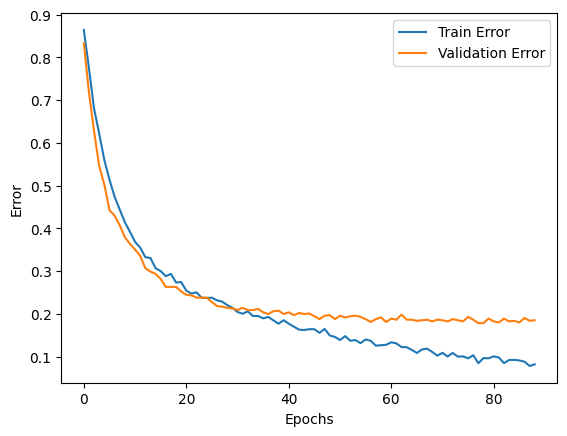

In [ ]:
class DelayedEarlyStopping(EarlyStopping):
    def __init__(self, start_epoch=50, **kwargs):
        super().__init__(**kwargs)
        self.start_epoch = start_epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.start_epoch:
            super().on_epoch_end(epoch, logs)
        else:
            self.wait = 0
            self.stopped_epoch = 0

early_efficientnet = DelayedEarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    start_epoch=50
)

checkpoint_efficientnet = ModelCheckpoint("best_efficientnet_model.h5", save_best_only=True)

history_efficientnet = efficientnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[early_efficientnet, checkpoint_efficientnet]
)

train_error = [1 - acc for acc in history_efficientnet.history['accuracy']]
val_error = [1 - acc for acc in history_efficientnet.history['val_accuracy']]

plt.plot(train_error, label='Train Error')
plt.plot(val_error, label='Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.show()

In [ ]:
def get_true_and_predicted_labels(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    return np.array(y_true), np.array(y_pred)

y_train_true, y_train_pred = get_true_and_predicted_labels(efficientnet_model, train_data)
y_val_true, y_val_pred = get_true_and_predicted_labels(efficientnet_model, val_data)
y_test_true, y_test_pred = get_true_and_predicted_labels(efficientnet_model, test_data)

print("Train Accuracy:", accuracy_score(y_train_true, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val_true, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test_true, y_test_pred))

Train Accuracy: 0.8775510204081632
Validation Accuracy: 0.8161375661375662
Test Accuracy: 0.8204592901878914


#### v. Report training, validation, and test Precision, Recall, AUC, and F1 score for those models. Is there a model that clearly outperforms others? Remember that this is a multi-class classification problem.

In [ ]:
def get_true_and_predicted_labels(model, dataset, num_classes=9):
    y_true = []
    y_pred = []
    y_probs = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_probs.extend(preds)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

    return y_true, y_pred, y_probs, y_true_bin

In [ ]:
def compute_overall_metrics(y_true, y_pred, y_probs, y_true_bin):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average='macro', zero_division=0),
        "AUC": roc_auc_score(y_true_bin, y_probs, average='macro', multi_class='ovr')
    }

In [ ]:
def evaluate_model(model, model_name, num_classes=9):
    metrics = {"Model": model_name}

    for split_name, dataset in [("Train", train_data), ("Validation", val_data), ("Test", test_data)]:
        y_true, y_pred, y_probs, y_true_bin = get_true_and_predicted_labels(model, dataset, num_classes)
        overall = compute_overall_metrics(y_true, y_pred, y_probs, y_true_bin)
        for metric, value in overall.items():
            metrics[f"{split_name} {metric}"] = value

    return metrics

In [ ]:
results = []
results.append(evaluate_model(vgg_model, "VGG16"))
results.append(evaluate_model(resnet50_model, "ResNet50"))
results.append(evaluate_model(resnet101_model, "ResNet101"))
results.append(evaluate_model(efficientnet_model, "EfficientNetB0"))
df_results = pd.DataFrame(results)
pd.set_option('display.precision', 4)
display(df_results)

,Model,Train Accuracy,Train Precision,Train Recall,Train F1 Score,Train AUC,Validation Accuracy,Validation Precision,Validation Recall,Validation F1 Score,Validation AUC,Test Accuracy,Test Precision,Test Recall,Test F1 Score,Test AUC
0,VGG16,0.8012,0.8048,0.7936,0.7972,0.9770,0.7619,0.7719,0.7506,0.7563,0.9634,0.7453,0.7440,0.7399,0.7396,0.9651
1,ResNet50,0.8624,0.8623,0.8707,0.8635,0.9905,0.7646,0.7718,0.7756,0.7683,0.9735,0.7860,0.7857,0.7978,0.7851,0.9728
2,ResNet101,0.8476,0.8571,0.8474,0.8498,0.9879,0.7685,0.7741,0.7659,0.7655,0.9716,0.7829,0.7861,0.7811,0.7797,0.9721
3,EfficientNetB0,0.8776,0.8785,0.8824,0.8783,0.9919,0.8161,0.8237,0.8239,0.8195,0.9793,0.8205,0.8212,0.8216,0.8150,0.9819


CONCLUSION:

No, none of the models clearly outperformed the others. All of them gave pretty similar results across training, validation, and test sets in terms of Precision, Recall, AUC, and F1 score. The accuracy was also quite close for all, so we can’t say one model was definitely better than the rest for this multi-class classification task.